# Data Quality Analysis

**Purpose**: Analyze the raw dataset to understand data quality, coverage, and field characteristics.

**Key Questions**:
1. How many fields are usable (high coverage)?
2. Which fields have NULL = FALSE semantics (boolean indicators)?
3. What are the contact field coverage rates?
4. What is the fraud rate and data distribution?

This notebook provides an interactive version of `src/utils/data_quality_report.py`.


In [1]:
import os
import sys
from pathlib import Path

# Set project root
PROJECT_ROOT = Path('/Users/dylan/Repos/ppa-fraud-notebook')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import polars as pl
import matplotlib.pyplot as plt
import numpy as np

ARTIFACTS_DIR = Path('artifacts')
print(f"Working directory: {os.getcwd()}")


Working directory: /Users/dylan/Repos/ppa-fraud-notebook


## 1. Load Raw Data & Basic Statistics


In [2]:
# Load raw insertions
raw_df = pl.read_parquet(ARTIFACTS_DIR / 'raw_insertions.parquet')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total Rows: {len(raw_df):,}")
print(f"Total Columns: {len(raw_df.columns)}")
print(f"\nDate Range:")
print(f"  From: {raw_df['submission_at'].min()}")
print(f"  To:   {raw_df['submission_at'].max()}")

# Fraud statistics
if 'fraud_flag' in raw_df.columns:
    fraud_count = raw_df['fraud_flag'].is_not_null().sum()
    fraud_rate = fraud_count / len(raw_df)
    print(f"\nFraud Statistics:")
    print(f"  Fraud Cases: {fraud_count:,}")
    print(f"  Fraud Rate: {fraud_rate:.2%}")


DATASET OVERVIEW
Total Rows: 234,458
Total Columns: 292

Date Range:
  From: 2023-01-01 07:36:27.382000+00:00
  To:   2025-11-01 23:43:13.152000+00:00

Fraud Statistics:
  Fraud Cases: 19,217
  Fraud Rate: 8.20%


## 2. Column Coverage Analysis


In [3]:
def is_boolean_indicator(col_name: str, dtype: str) -> bool:
    """Detect boolean indicator fields where NULL = FALSE."""
    if dtype != "Boolean":
        return False
    field_name = col_name.split(".")[-1].lower()
    prefixes = ("is", "has", "are", "can", "allow")
    for prefix in prefixes:
        if field_name.startswith(prefix):
            return True
    return False

# Calculate coverage for all columns
n_rows = len(raw_df)
stats = []

for col in raw_df.columns:
    dtype = str(raw_df[col].dtype)
    null_count = raw_df[col].is_null().sum()
    null_pct = null_count / n_rows * 100
    non_null_pct = 100 - null_pct
    is_indicator = is_boolean_indicator(col, dtype)
    semantic_coverage = 100.0 if is_indicator else non_null_pct
    
    stats.append({
        'column': col,
        'dtype': dtype,
        'null_pct': null_pct,
        'non_null_pct': non_null_pct,
        'is_boolean_indicator': is_indicator,
        'semantic_coverage': semantic_coverage
    })

coverage_df = pl.DataFrame(stats).sort('semantic_coverage', descending=True)

# Summary
high_cov = coverage_df.filter(pl.col('semantic_coverage') >= 50)
medium_cov = coverage_df.filter((pl.col('semantic_coverage') >= 10) & (pl.col('semantic_coverage') < 50))
low_cov = coverage_df.filter(pl.col('semantic_coverage') < 10)
bool_ind = coverage_df.filter(pl.col('is_boolean_indicator'))

print("=" * 60)
print("COVERAGE SUMMARY")
print("=" * 60)
print(f"High Coverage (>=50%):    {len(high_cov):3d} columns")
print(f"Medium Coverage (10-50%): {len(medium_cov):3d} columns")
print(f"Low Coverage (<10%):      {len(low_cov):3d} columns")
print(f"\nBoolean Indicators:       {len(bool_ind):3d} columns (NULL = FALSE)")


COVERAGE SUMMARY
High Coverage (>=50%):    125 columns
Medium Coverage (10-50%):  15 columns
Low Coverage (<10%):      152 columns

Boolean Indicators:        47 columns (NULL = FALSE)


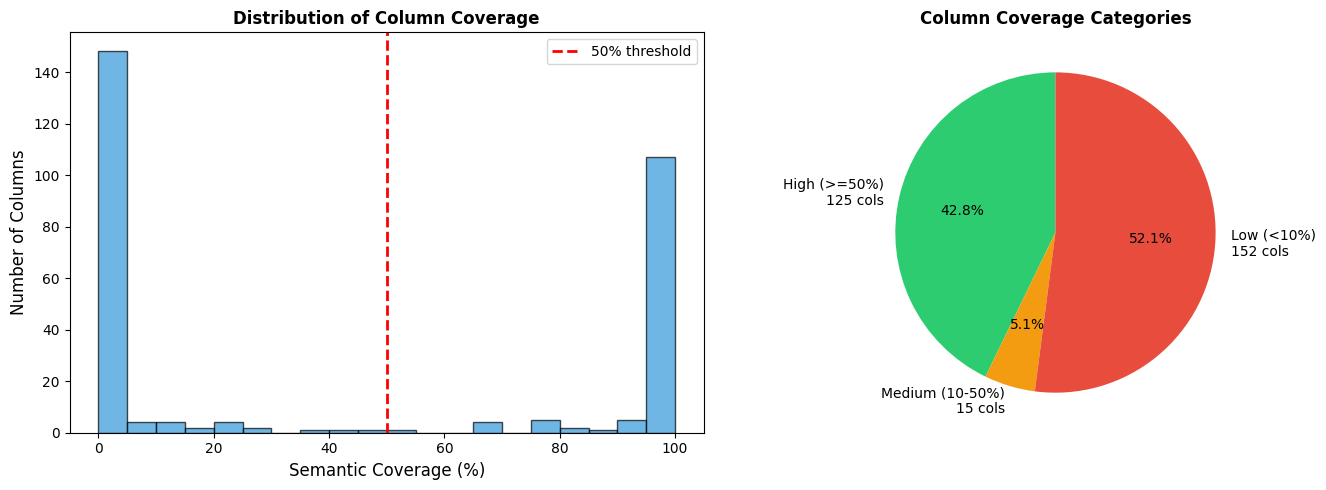

In [4]:
# Visualize coverage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(coverage_df['semantic_coverage'].to_numpy(), bins=20, edgecolor='black', alpha=0.7, color='#3498db')
ax1.axvline(50, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax1.set_xlabel('Semantic Coverage (%)', fontsize=12)
ax1.set_ylabel('Number of Columns', fontsize=12)
ax1.set_title('Distribution of Column Coverage', fontweight='bold')
ax1.legend()

# Pie chart
ax2 = axes[1]
sizes = [len(high_cov), len(medium_cov), len(low_cov)]
labels = [f'High (>=50%)\n{sizes[0]} cols', f'Medium (10-50%)\n{sizes[1]} cols', f'Low (<10%)\n{sizes[2]} cols']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Column Coverage Categories', fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Boolean Indicator Fields (NULL = FALSE Semantics)

**Key Finding**: These boolean fields use NULL to indicate FALSE (feature not present).
They have 100% semantic coverage and are safe to use in modeling.


In [5]:
# Show boolean indicator fields
print("=" * 70)
print("BOOLEAN INDICATOR FIELDS (NULL = FALSE semantics)")
print("=" * 70)
print(f"\n{'Field':<55} {'TRUE %':>8} {'NULL(=FALSE) %':>14}")
print("-" * 77)

for row in bool_ind.head(25).iter_rows(named=True):
    true_pct = row['non_null_pct']
    false_pct = 100 - true_pct
    print(f"{row['column']:<55} {true_pct:>7.1f}% {false_pct:>13.1f}%")

if len(bool_ind) > 25:
    print(f"\n... and {len(bool_ind) - 25} more boolean indicator fields")


BOOLEAN INDICATOR FIELDS (NULL = FALSE semantics)

Field                                                     TRUE % NULL(=FALSE) %
-----------------------------------------------------------------------------
auto_approval_criteria.criteria.hasUsedSameEmailBefore     98.8%           1.2%
listing.autoApprovalCriteria.criteria.hasUsedSameEmailBefore     0.0%         100.0%
listing.characteristics.arePetsAllowed                     28.4%          71.6%
listing.characteristics.hasAttic                            0.0%         100.0%
listing.characteristics.hasBalcony                         71.2%          28.8%
listing.characteristics.hasBuildingLawRestrictions          0.0%         100.0%
listing.characteristics.hasCableTv                         14.8%          85.2%
listing.characteristics.hasCellar                           0.0%         100.0%
listing.characteristics.hasConnectedBuildingLand            0.0%         100.0%
listing.characteristics.hasDishwasher                       3.9%  

## 4. Top High-Coverage Fields (for Feature Engineering)


In [6]:
# Top high-coverage non-boolean fields (candidates for features)
non_bool_high = coverage_df.filter(
    (pl.col('semantic_coverage') >= 80) & 
    (~pl.col('is_boolean_indicator'))
).head(30)

print("=" * 75)
print("TOP HIGH-COVERAGE FIELDS (>=80%, non-boolean)")
print("=" * 75)
print(f"\n{'Column':<50} {'Coverage':>10} {'Type':>15}")
print("-" * 75)

for row in non_bool_high.iter_rows(named=True):
    print(f"{row['column']:<50} {row['semantic_coverage']:>9.1f}% {row['dtype']:>15}")


TOP HIGH-COVERAGE FIELDS (>=80%, non-boolean)

Column                                               Coverage            Type
---------------------------------------------------------------------------
account_created_at                                     100.0% Datetime(time_unit='us', time_zone='UTC')
listing.address.address_hash                           100.0%          String
listing.address.country_hash                           100.0%          String
listing.contactForm.deliveryFormat                     100.0%          String
listing.contactForm.size                               100.0%          String
listing.externalIds.internalReferenceId                100.0%          String
listing.externalIds.propertyReferenceId                100.0%          String
listing.legacy.personId                                100.0%           Int64
listing.lister.id                                      100.0%          String
listing.lister.username                                100.0%          

## 5. Contact Fields Analysis (Graph Construction)


In [7]:
# Analyze contact fields (important for graph construction)
phone_cols = [c for c in raw_df.columns if 'phone' in c.lower() and 'type' not in c.lower()]
email_cols = [c for c in raw_df.columns if 'email' in c.lower()]
address_cols = [c for c in raw_df.columns if any(t in c.lower() for t in ['address', 'street', 'zip', 'city'])]

def show_contact_stats(cols, name):
    print(f"\n{name.upper()} FIELDS ({len(cols)} found):")
    print("-" * 60)
    sorted_cols = sorted(cols, key=lambda c: raw_df[c].is_null().sum())
    for col in sorted_cols[:8]:
        coverage = (1 - raw_df[col].is_null().sum() / len(raw_df)) * 100
        print(f"  {col:<45} {coverage:5.1f}%")
    if len(cols) > 8:
        print(f"  ... and {len(cols) - 8} more")

print("=" * 60)
print("CONTACT FIELDS ANALYSIS")
print("=" * 60)
show_contact_stats(phone_cols, "Phone")
show_contact_stats(email_cols, "Email")
show_contact_stats(address_cols, "Address")


CONTACT FIELDS ANALYSIS

PHONE FIELDS (21 found):
------------------------------------------------------------
  listing.lister.billing.phoneDay.hash           98.0%
  listing.lister.billing.phoneDay.number_hash    98.0%
  listing.lister.billing.phoneDay.area_hash      98.0%
  listing.lister.billing.phoneDay.country_hash   95.8%
  listing.lister.phone.hash                      70.0%
  listing.lister.phone.number_hash               70.0%
  listing.lister.phone.area_hash                 70.0%
  listing.lister.phone.country_hash              68.9%
  ... and 13 more

EMAIL FIELDS (16 found):
------------------------------------------------------------
  listing.lister.email.hash                     100.0%
  listing.lister.email.domain_hash              100.0%
  listing.lister.email.user_hash                100.0%
  auto_approval_criteria.criteria.hasUsedSameEmailBefore  98.8%
  listing.lister.billing.email.hash              98.0%
  listing.lister.billing.email.domain_hash       98.0%
  lis

## 6. Summary & Implications for Modeling


In [8]:
print("=" * 70)
print("KEY FINDINGS - DATA QUALITY SUMMARY")
print("=" * 70)

print(f"""
📊 DATASET OVERVIEW
   • Total Rows: {len(raw_df):,}
   • Total Columns: {len(raw_df.columns)}
   • Fraud Rate: {fraud_rate:.2%}

📈 COVERAGE ANALYSIS
   • High Coverage (>=50%): {len(high_cov)} columns
   • Medium Coverage (10-50%): {len(medium_cov)} columns  
   • Low Coverage (<10%): {len(low_cov)} columns

🔘 BOOLEAN INDICATOR DISCOVERY
   • Found {len(bool_ind)} boolean indicator fields
   • These use NULL = FALSE semantics
   • All have 100% semantic coverage

📞 CONTACT FIELDS (for Graph Construction)
   • Phone fields: {len(phone_cols)}
   • Email fields: {len(email_cols)}
   • Address fields: {len(address_cols)}

💡 IMPLICATIONS FOR MODELING
   1. {len(high_cov)} fields are usable for feature engineering
   2. Boolean indicators can be safely used (NULL = FALSE)
   3. Contact fields enable graph edge construction
   4. Phone edges should be unified (billing + lister phone)
""")


KEY FINDINGS - DATA QUALITY SUMMARY

📊 DATASET OVERVIEW
   • Total Rows: 234,458
   • Total Columns: 292
   • Fraud Rate: 8.20%

📈 COVERAGE ANALYSIS
   • High Coverage (>=50%): 125 columns
   • Medium Coverage (10-50%): 15 columns  
   • Low Coverage (<10%): 152 columns

🔘 BOOLEAN INDICATOR DISCOVERY
   • Found 47 boolean indicator fields
   • These use NULL = FALSE semantics
   • All have 100% semantic coverage

📞 CONTACT FIELDS (for Graph Construction)
   • Phone fields: 21
   • Email fields: 16
   • Address fields: 35

💡 IMPLICATIONS FOR MODELING
   1. 125 fields are usable for feature engineering
   2. Boolean indicators can be safely used (NULL = FALSE)
   3. Contact fields enable graph edge construction
   4. Phone edges should be unified (billing + lister phone)

